# Karnataka Crop Advisory Dataset — Exploratory Data Analysis

**Author:** R Megha Ganesh, BE ECE, DSCE Bangalore  
**Project:** Smart Crop Advisory System — BE Final Year Project  
**Guide:** Dr. Nagarathna

---

This dataset was built for our BE project on IoT-based smart crop recommendation.
Since no large-scale Karnataka-specific dataset existed publicly, we built this
semi-synthetic dataset using real government sources:

- **IMD** — District-level seasonal rainfall normals
- **NBSS&LUP 1998** — Karnataka soil classification maps  
- **ICAR 2017** — Crop NPK requirements and production guidelines
- **UAS Bangalore / IISc** — Agro-climatic zone mappings

The dataset covers 39 crops, 31 districts, 3 seasons across Karnataka's
10 agro-climatic zones. Total: 21,960 rows, 12 features, zero nulls.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# keeping this consistent throughout the notebook
np.random.seed(42)
sns.set_theme(style='whitegrid')

df = pd.read_csv('karnataka_crop_dataset_V2.csv')

# quick sanity check first
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nNo. of unique crops:", df['label'].nunique())
print("No. of districts:", df['district'].nunique())
print("Seasons:", df['season'].unique())
print("\nNull values:")
print(df.isnull().sum())

Shape: (21960, 12)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'soil_type', 'season', 'district', 'region', 'label']

No. of unique crops: 39
No. of districts: 31
Seasons: ['Kharif' 'Rabi' 'Zaid']

Null values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
soil_type      0
season         0
district       0
region         0
label          0
dtype: int64


## 1. Dataset Overview
Basic stats and structure of the dataset.

In [3]:
# just checking basic stats for all numeric columns
# useful to see if ranges make agronomic sense

df.describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,21960.00,21960.00,21960.00,21960.00,21960.00,21960.00,21960.00
mean,87.39,44.17,81.80,26.73,64.88,6.44,475.73
std,51.96,13.35,45.96,3.81,13.03,0.51,629.36
min,15.00,20.00,15.02,15.01,30.01,4.53,53.74
25%,53.39,37.29,46.28,24.17,55.68,6.11,156.36
50%,76.98,43.00,68.52,26.48,65.02,6.45,283.49
75%,113.21,50.03,108.04,29.21,75.13,6.78,430.14
max,279.78,99.95,199.99,37.99,95.00,8.00,3678.95


## 2. Crop Distribution
How many rows per crop — this reflects real agricultural prevalence in Karnataka,
not equal sampling. Banana and coconut dominate because they genuinely have the
widest district coverage in the state.

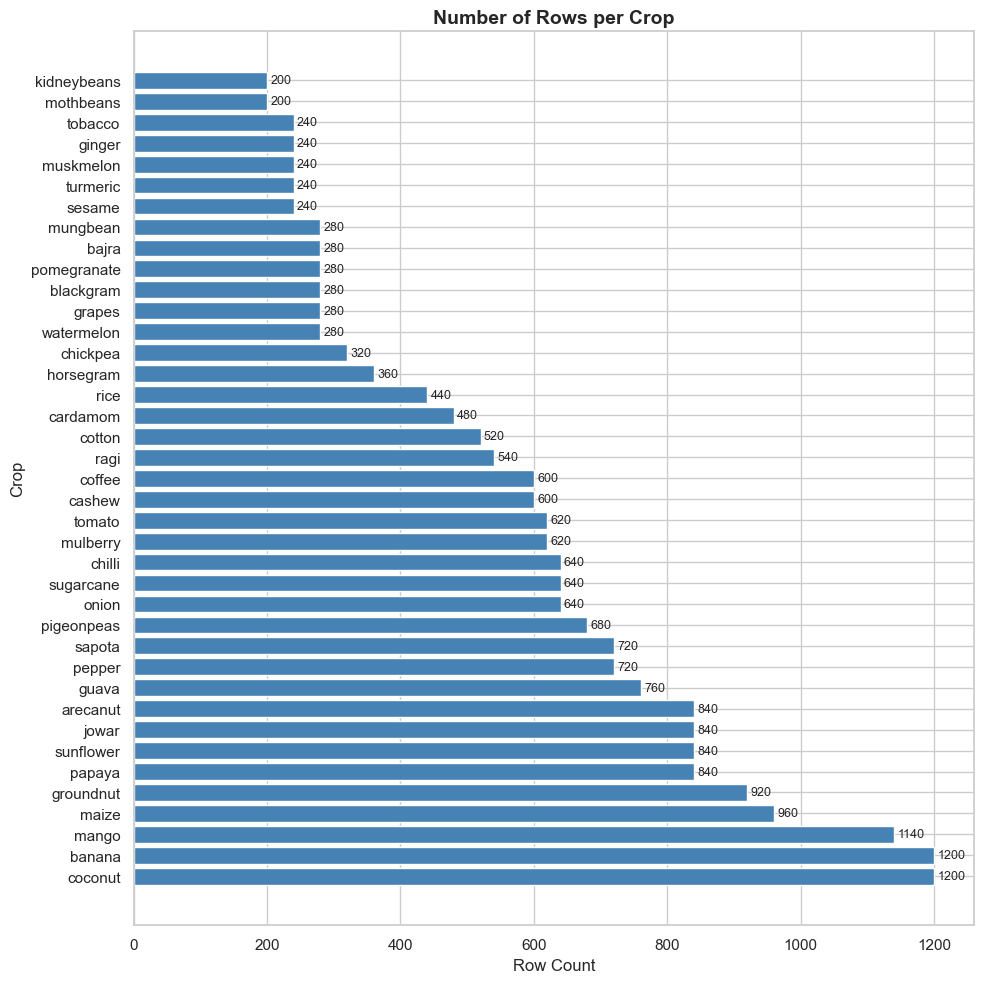

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))

crop_counts = df['label'].value_counts()

# horizontal bar makes crop names readable
bars = ax.barh(crop_counts.index, crop_counts.values, color='steelblue', edgecolor='white')

# adding count labels at end of each bar
for bar, val in zip(bars, crop_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_title('Number of Rows per Crop', fontsize=14, fontweight='bold')
ax.set_xlabel('Row Count')
ax.set_ylabel('Crop')
plt.tight_layout()
plt.savefig('plot1_crop_distribution.png', dpi=150)
plt.show()

## 3. Season and Region Distribution
Kharif dominates because most Karnataka crops are rain-fed.

C:\Users\rmegh\AppData\Local\Temp\ipykernel_1944\4019452697.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.values, y=region_counts.index,


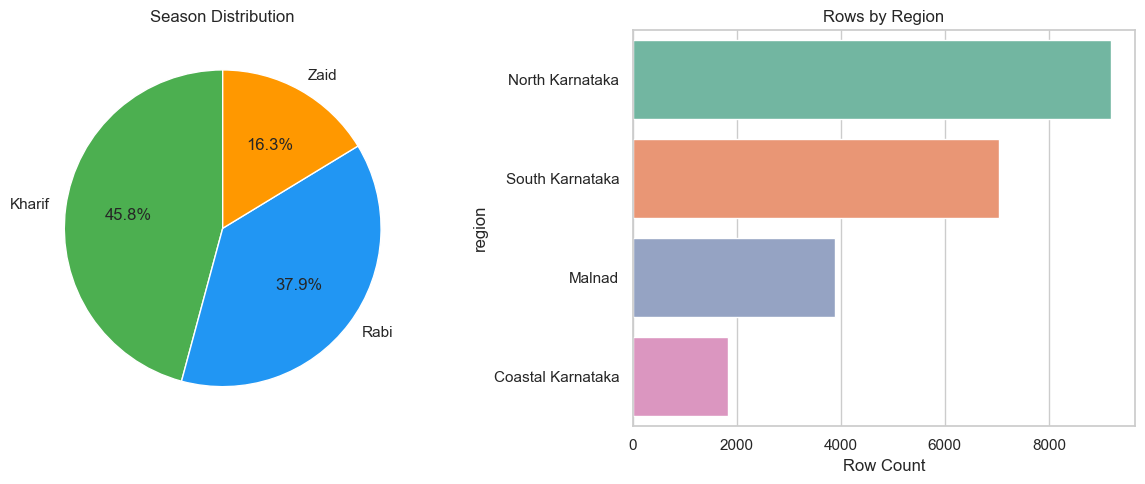

In [5]:
ig, axes = plt.subplots(1, 2, figsize=(12, 5))

# season pie
season_counts = df['season'].value_counts()
axes[0].pie(season_counts.values,
            labels=season_counts.index,
            autopct='%1.1f%%',
            colors=['#4CAF50', '#2196F3', '#FF9800'],
            startangle=90)
axes[0].set_title('Season Distribution')

# region bar
region_counts = df['region'].value_counts()
sns.barplot(x=region_counts.values, y=region_counts.index,
            ax=axes[1], palette='Set2')
axes[1].set_title('Rows by Region')
axes[1].set_xlabel('Row Count')

plt.tight_layout()
plt.savefig('plot2_season_region.png', dpi=150)
plt.show()

## 4. District × Crop Heatmap
This is probably the most useful plot in this notebook.
It shows which crops are grown in which districts — built from
Karnataka Agriculture Department records and ICAR crop calendars.

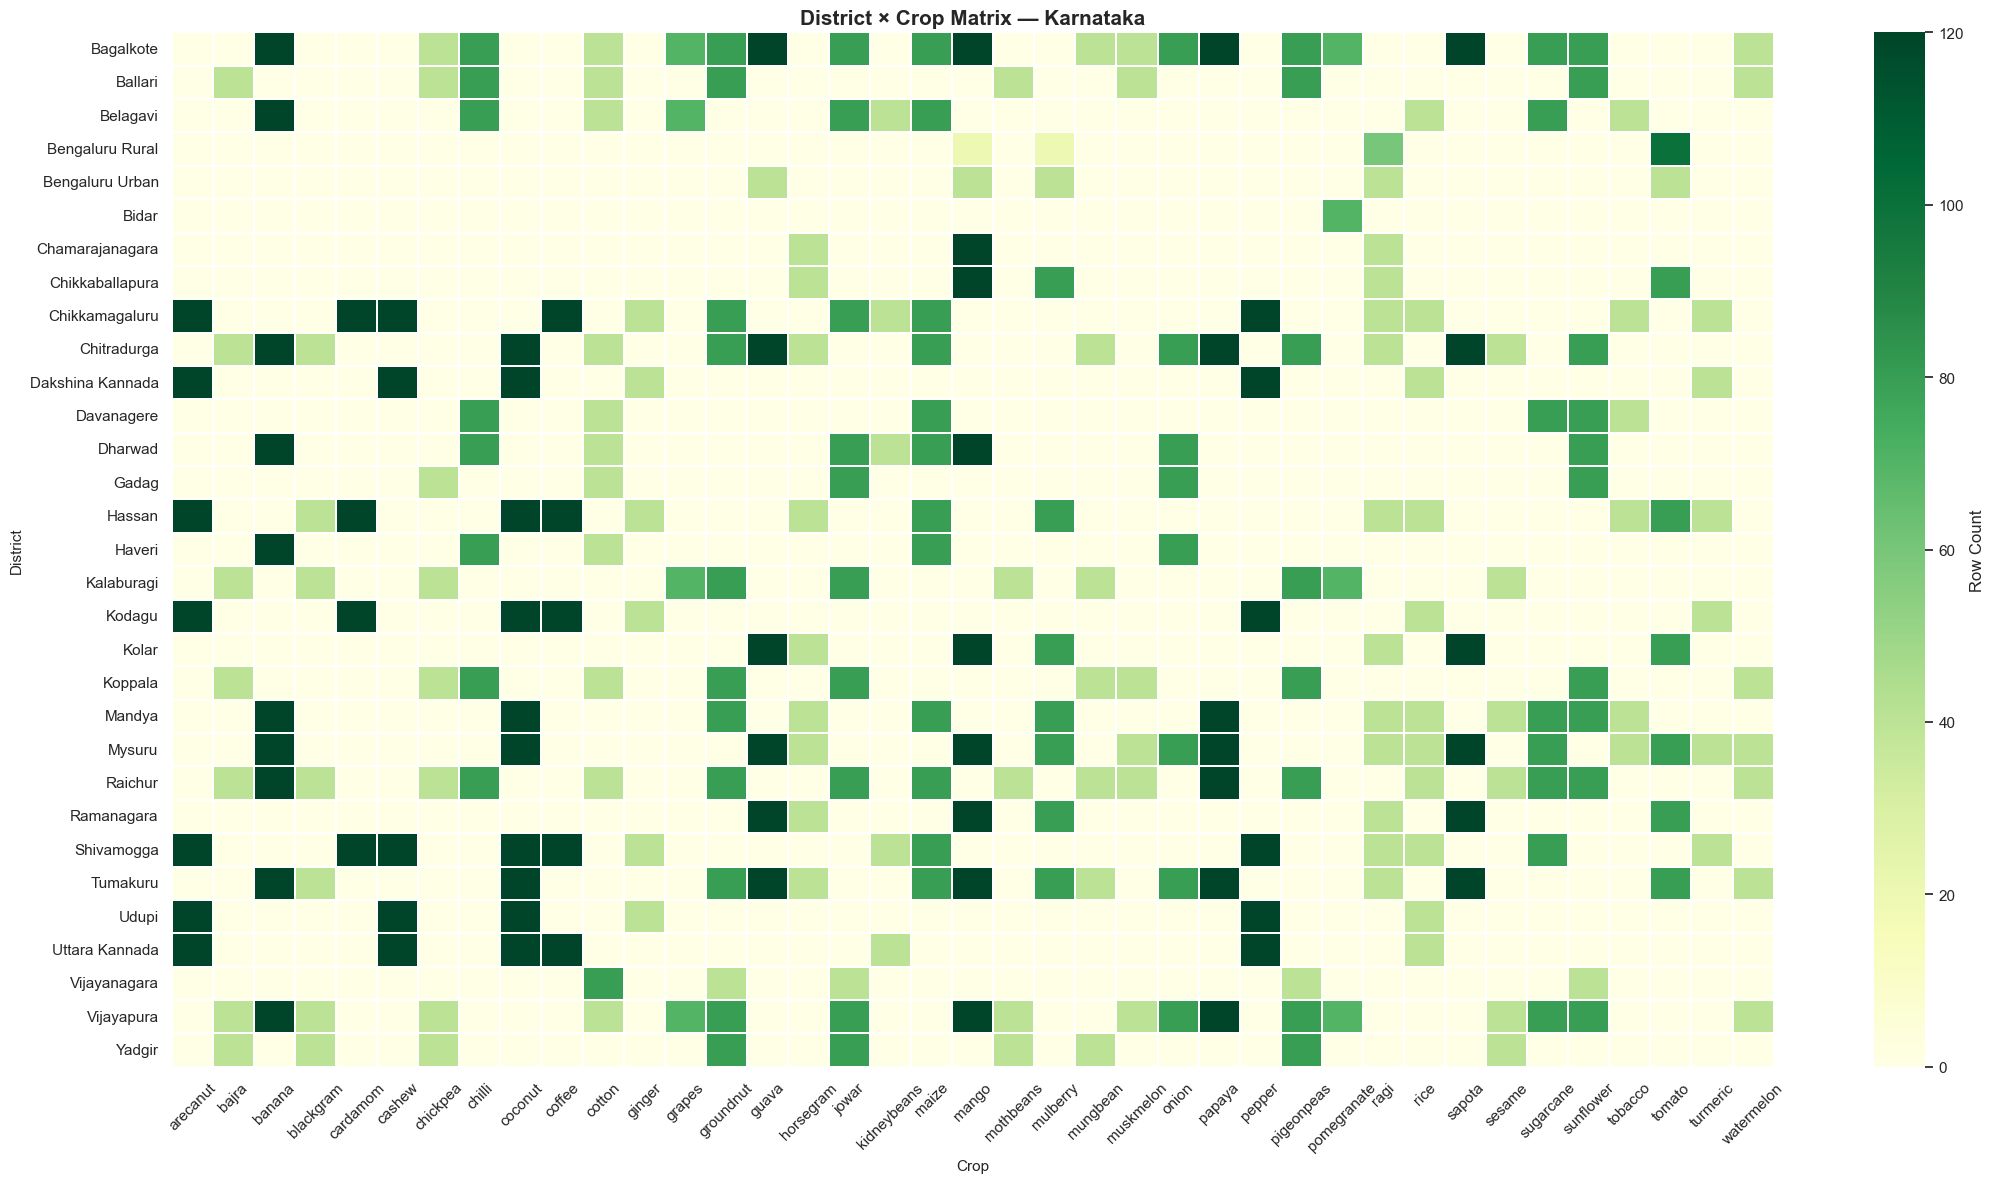

In [6]:
# pivot table: districts as rows, crops as columns, value = row count
pivot = df.groupby(['district', 'label']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(22, 12))
sns.heatmap(pivot, cmap='YlGn', linewidths=0.3,
            linecolor='white', ax=ax, cbar_kws={'label': 'Row Count'})

ax.set_title('District × Crop Matrix — Karnataka', fontsize=15, fontweight='bold')
ax.set_xlabel('Crop', fontsize=11)
ax.set_ylabel('District', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('plot3_district_crop_heatmap.png', dpi=150)
plt.show()

## 5. NPK Distribution by Soil Type
Source: ICAR Soil Fertility Guidelines 2017.
Different soil types have fundamentally different nutrient profiles —
this drives a lot of the model's decision making.

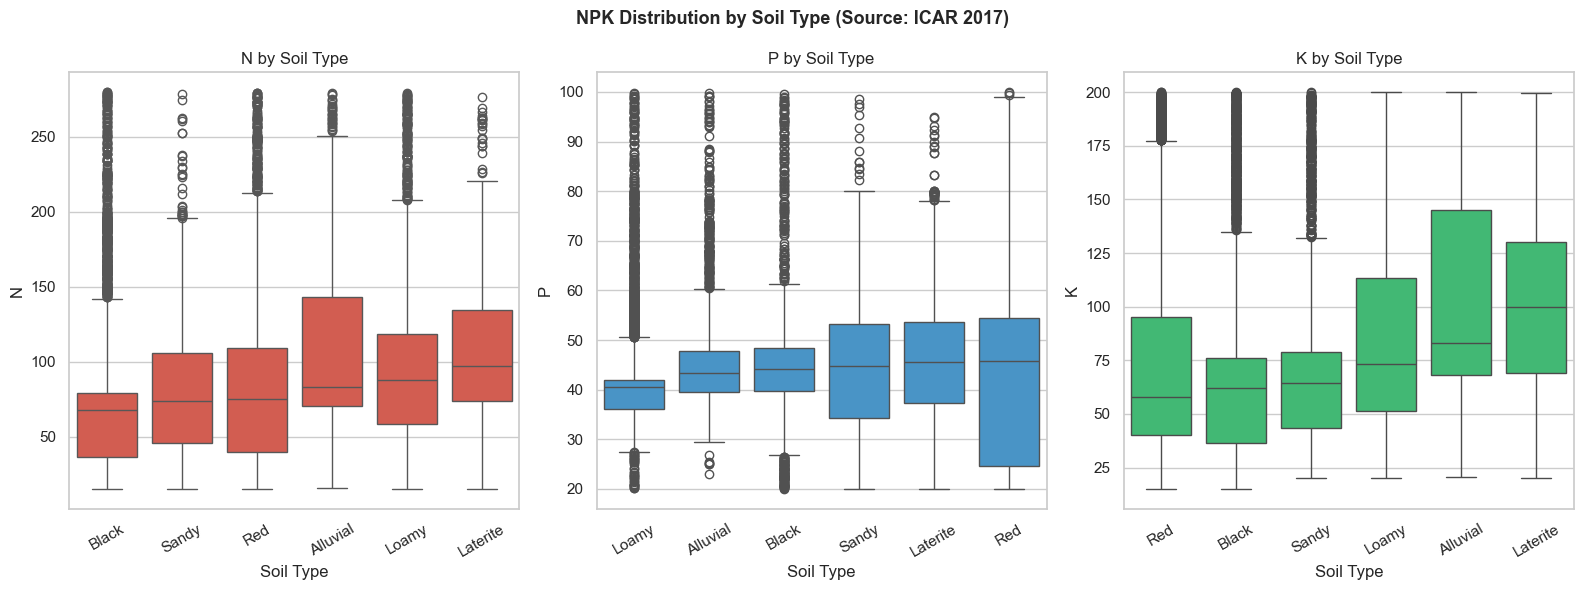

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

nutrients = ['N', 'P', 'K']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, (nutrient, color) in enumerate(zip(nutrients, colors)):
    # boxplot per soil type for each nutrient
    soil_order = df.groupby('soil_type')[nutrient].median().sort_values().index
    sns.boxplot(data=df, x='soil_type', y=nutrient,
                order=soil_order, ax=axes[i], color=color)
    axes[i].set_title(f'{nutrient} by Soil Type')
    axes[i].set_xlabel('Soil Type')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('NPK Distribution by Soil Type (Source: ICAR 2017)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_npk_soil.png', dpi=150)
plt.show()

## 6. Feature Correlation
Checking if any features are highly correlated — important for ML model quality.

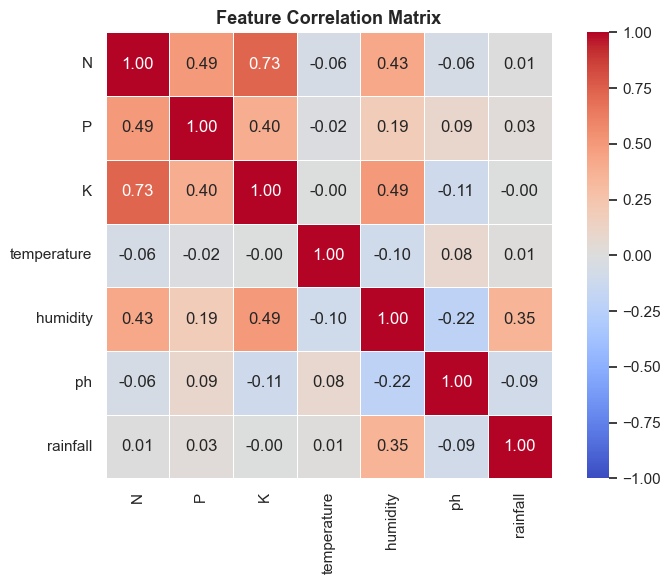

Max correlation (excluding diagonal):
0.733


In [8]:
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax,
            square=True, linewidths=0.5,
            vmin=-1, vmax=1)

ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_correlation.png', dpi=150)
plt.show()

# ideally want low correlation between features for a clean ML dataset
print("Max correlation (excluding diagonal):")
corr_no_diag = corr.where(~np.eye(len(corr), dtype=bool))
print(round(corr_no_diag.abs().max().max(), 3))

## 7. Climate Profile by Zone
Temperature vs Humidity coloured by Karnataka's agro-climatic zones.
Should see clear separation — coastal is hot+humid, NE dry is hot+dry.

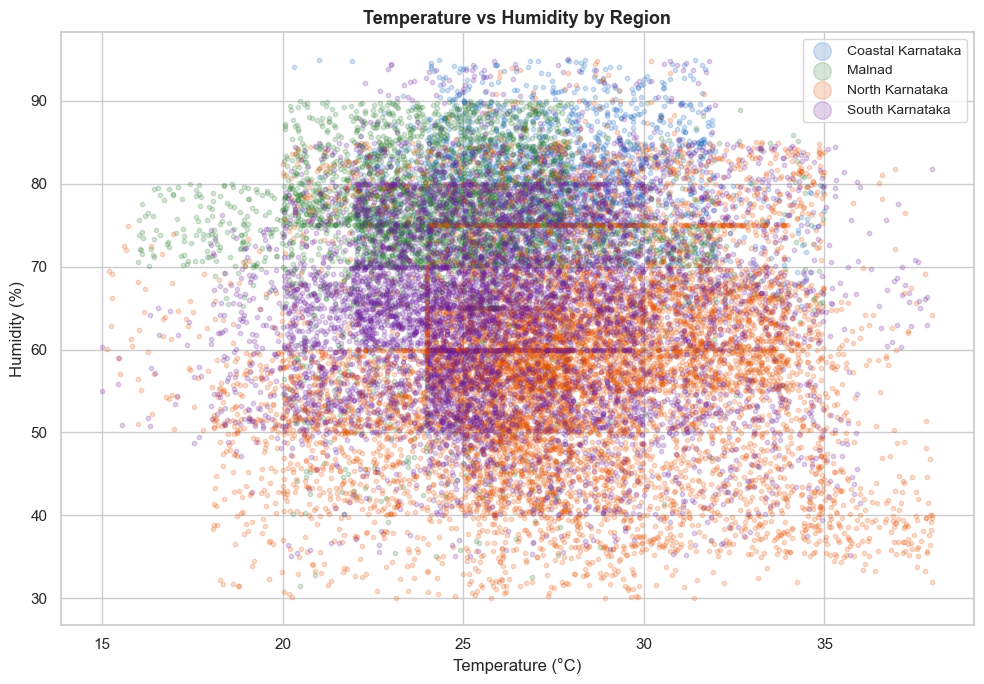

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

region_colors = {
    'Coastal Karnataka': '#1565C0',
    'Malnad':            '#2E7D32',
    'North Karnataka':   '#E65100',
    'South Karnataka':   '#6A1B9A'
}

for region, color in region_colors.items():
    subset = df[df['region'] == region]
    ax.scatter(subset['temperature'], subset['humidity'],
               alpha=0.2, label=region, color=color, s=10)

ax.set_title('Temperature vs Humidity by Region', fontsize=13, fontweight='bold')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Humidity (%)')
ax.legend(markerscale=4, fontsize=10)
plt.tight_layout()
plt.savefig('plot6_climate_zones.png', dpi=150)
plt.show()

## Summary

| Property | Value |
|---|---|
| Total rows | 21,960 |
| Features | 12 |
| Crops | 39 |
| Districts | 31 |
| Seasons | 3 (Kharif, Rabi, Zaid) |
| Null values | 0 |
| RF Accuracy | 91.33% |

*Data sources:* IMD, NBSS&LUP, ICAR, UAS Bangalore, Karnataka Agriculture Dept  
*Use case:* Crop recommendation model training for IoT-based advisory systems  
*Built by:* R Megha Ganesh, DSCE Bangalore, 2026